# Detecting Illicit Bitcoin Transactions

***Dataset name:*** Elliptic++ Bitcoin Blockchain Dataset

***Github:*** https://github.com/git-disl/EllipticPlusPlus/tree/main/Transactions%20Dataset

***Research paper:*** https://ieeexplore.ieee.org/abstract/document/9916625

***Course topic alignment:***
- Graph Mining
- Large-Scale ML
- Anomaly Detection
- Graph Embeddings

***Potential beyond-course techniques:***
- Graph Neural Networks (GCN)
- Semi-supervised learning using "unkown" labels

***Dataset size and structure (from github documentation):***
- Nodes (transactions): 203,769
- Edges (money flow): 234,355
- Time steps: 49
- Illicit (class-1): 4,545
- Licit (class-2): 42,019
- Unknown (class-3): 157,205
- Features: 18

***Data types:***
- Transaction ID (unique identifiers)
- Directed edges (money flow between transactions)
- 18 numerical transaction features
- Class label (licit/illicit/unknown)
- Discrete Time index

***Target variables:***
- Binary fraud classification: illicit vs licit transaction

***Licensing or usage constraints:***
- Public research dataset
- Intended for academic research use

## Project Overview

This project investigates the problem of detecting illicit financial activity using the Elliptic++ Bitcoin transaction dataset. The dataset represents a large transaction network where nodes correspond to transactions and edges represent money flow over time.

The goal is to evaluate multiple approaches for fraud detection, including:
- Structural graph analysis
- Anomaly detection
- Supervised machine learning
- Graph-based models

A key challenge is that illicit transactions are both rare (class imbalance) and often behaviorally similar to normal transactions, making them difficult to detect.

This project aims to understand not only which methods perform best, but why fraud detection is inherently difficult in real-world systems.

### Import libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict

### Load data

In [23]:
features = pd.read_csv("txs_features.csv")
classes  = pd.read_csv("txs_classes.csv")
edges    = pd.read_csv("txs_edgelist.csv")

features.columns = features.columns.str.strip()
classes.columns  = classes.columns.str.strip()
edges.columns    = edges.columns.str.strip()

# display data
print("Features shape:", features.shape)
print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

print("\nFeatures:")
display(features.head())
print("\nClasses:")
display(classes.head())
print("\nEdges:")
display(edges.head())

Features shape: (203769, 184)
Classes shape: (203769, 2)
Edges shape: (234355, 2)

Features:


,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680



Classes:


,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2



Edges:


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [24]:
print("features txId unique:", features["txId"].nunique())
print("classes txId unique :", classes["txId"].nunique())

print("features txId dtype:", features["txId"].dtype)
print("classes txId dtype :", classes["txId"].dtype)

# missing values quick scan
print("\nMissing values (features) top 10:")
display(features.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values (classes):")
display(classes.isna().sum())

print("\nMissing values (edges):")
display(edges.isna().sum())

# duplicates
print("\nDuplicate txId (features):", features["txId"].duplicated().sum())
print("Duplicate txId (classes) :", classes["txId"].duplicated().sum())
print("Duplicate edges:", edges.duplicated().sum())

features txId unique: 203769
classes txId unique : 203769
features txId dtype: int64
classes txId dtype : int64

Missing values (features) top 10:


,0
in_BTC_mean,965
in_BTC_median,965
in_BTC_total,965
out_BTC_min,965
out_BTC_max,965
out_BTC_mean,965
out_BTC_median,965
out_txs_degree,965
in_txs_degree,965
total_BTC,965



Missing values (classes):


,0
txId,0
class,0



Missing values (edges):


,0
txId1,0
txId2,0



Duplicate txId (features): 0
Duplicate txId (classes) : 0
Duplicate edges: 0


## Data Understanding & EDA

Before applying models, we analyze the dataset to understand:
- Class imbalance
- Feature distributions
- Temporal structure
- Graph properties

Understanding these characteristics is critical because fraud detection performance is heavily influenced by data distribution and imbalance.

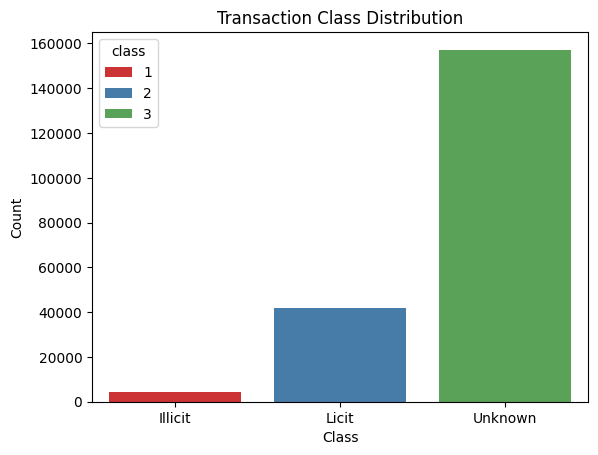

In [25]:
# number of transactions by class
features.insert(loc=2, column='class', value=classes['class'])
features['class'].value_counts()

ax = sns.countplot(x="class", data=features, palette='Set1', hue='class')
ax.set_xticklabels(['Illicit', 'Licit', 'Unknown'])
plt.title('Transaction Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Unmapped labels (no time step found): 0


class,1,2,3
Time step,,,
1,17,2130,5733
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921


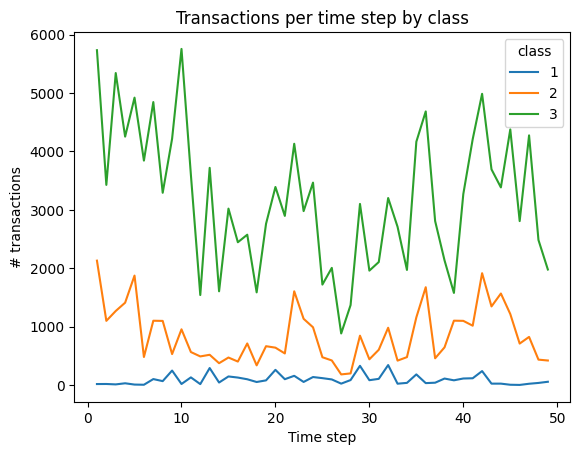

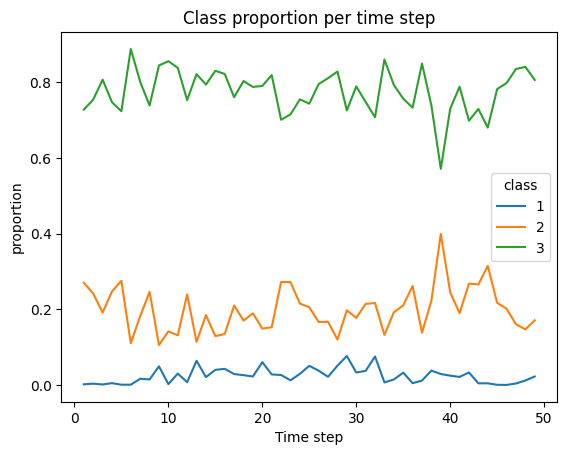

In [26]:
# number of transactions by time step
tx_to_time = dict(zip(features["txId"], features["Time step"]))
tx_to_class = dict(zip(features["txId"], features["class"]))

classes_ts = classes.copy()
classes_ts["Time step"] = classes_ts["txId"].map(tx_to_time)

# check how many txIds failed to map
print("Unmapped labels (no time step found):", classes_ts["Time step"].isna().sum())

ct = classes_ts.groupby(["Time step", "class"]).size().unstack(fill_value=0).sort_index()
display(ct.head())

ct.plot()
plt.title("Transactions per time step by class")
plt.xlabel("Time step")
plt.ylabel("# transactions")
plt.show()

# proportions by time
ct_prop = ct.div(ct.sum(axis=1), axis=0)
ct_prop.plot()
plt.title("Class proportion per time step")
plt.xlabel("Time step")
plt.ylabel("proportion")
plt.show()

### Key Observations

The dataset exhibits extreme class imbalance across all time stepes, with illicit transactions representing only a tiny fraction of total activity. The unknown class constitutes the majority of transactions across all time steps, indicating that most transactions lack known labels. This suggests that semi-surpervised or unsupervised methods may be appropriate for leveraging unlabeled data.

Transaction counts vary across time steps, indicating the networ activity is dynamic rather than constant. The temporal variability supports the use of time-aware models. The sparsity of illicit transactions suggests the detection may require tempral context rather than relying solely on individual transaction features.

### Feature Analysis

Feature distributions show significant overlap between licit and illicit transactions.

This suggests:
- Fraudulent behavior is not easily separable
- Simple threshold-based or anomaly methods may struggle
- More complex models may be needed to capture subtle patterns

,Feature,Imp
169,size,0.046272
54,Local_feature_55,0.044621
17,Local_feature_18,0.043210
46,Local_feature_47,0.040056
52,Local_feature_53,0.039920
171,num_output_addresses,0.038125
40,Local_feature_41,0.029631
22,Local_feature_23,0.027111
131,Aggregate_feature_39,0.026706
89,Local_feature_90,0.026553


<Figure size 1000x800 with 0 Axes>

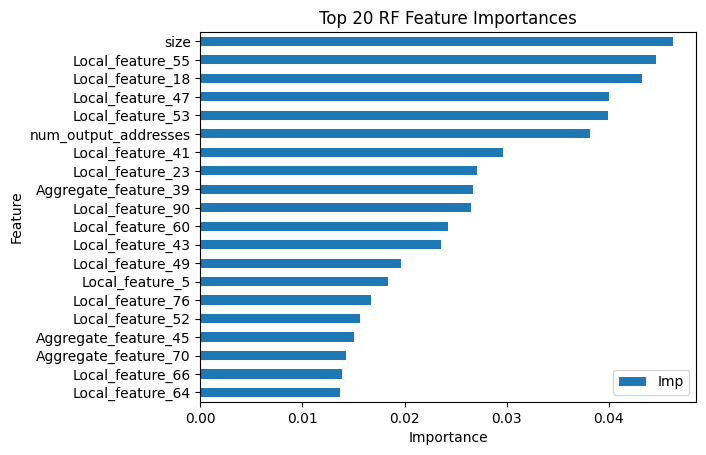

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# labeled only
df_lab = features[features["class"].isin([1,2])].copy()

X = df_lab.drop(columns=["txId", "Time step", "class"])
y = df_lab["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# train RF
cRF = RandomForestClassifier(
    n_estimators=50,   # reduced for speed
    random_state=42,
    n_jobs=-1
)

cRF.fit(X_train, y_train)

# feature importance
imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Imp": cRF.feature_importances_
}).sort_values("Imp", ascending=False)

display(imp_df.head(20))

plt.figure(figsize=(10, 8))
imp_df.head(20).iloc[::-1].plot(kind="barh", x="Feature", y="Imp")
plt.title("Top 20 RF Feature Importances")
plt.xlabel("Importance")
plt.show()


Feature importance analysis indicates that both transaction-level attributes and graph-based features contribute to distinguishing transaction classes. Transaction size emerged as the most informative feature, suggesting systematic differences in transaction magnitude between illicit and licit behavior. The number of output addresses was also highly important, consistent with the use of address-splitting strategies to obsure fund flows. The relatively similar importance values across features suggest that illicit detection relies on a combination of factors rather than a single dominant indicator.

## RQ1 - Structural Graph Analysis

We analyze whether illicit transactions occupy distinct positions in the network.

*Hypothesis:*
If fraud behaves differently structurally, metrics like degree, PageRank, or centrality should differ between illicit and licit nodes.

### Graph Construction

We construct a directed graph where:
- Nodes represent transactions  
- Edges represent money flow between transactions  

We also attach metadata:
- Class labels (illicit, licit, unknown)
- Time step information

This allows us to analyze both structural and temporal properties of the network

In [28]:
# build directed graph
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

# attach labels and time step metadata
tx_to_class = dict(zip(features["txId"], features["class"]))
tx_to_time  = dict(zip(features["txId"], features["Time step"]))

nx.set_node_attributes(G, tx_to_class, "class")
nx.set_node_attributes(G, tx_to_time,  "Time step")

print("Graph basics")
print("Nodes   :", G.number_of_nodes())
print("Edges   :", G.number_of_edges())
print("Density :", nx.density(G))

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

node_df = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_deg": [in_deg[n] for n in G.nodes()],
    "out_deg": [out_deg[n] for n in G.nodes()],
    "degree_total": [in_deg[n] + out_deg[n] for n in G.nodes()],
    "class": [G.nodes[n].get("class", np.nan) for n in G.nodes()],
    "Time step": [G.nodes[n].get("Time step", np.nan) for n in G.nodes()],
})

display(node_df.head())

Graph basics
Nodes   : 203769
Edges   : 234355
Density : 5.644170528459417e-06


,txId,in_deg,out_deg,degree_total,class,Time step
0,230425980,1,1,2,3,1
1,5530458,1,1,2,3,1
2,232022460,1,2,3,3,1
3,232438397,160,1,161,2,1
4,230460314,2,8,10,3,1


### Observations

The graph contains over 200,000 nodes and is extremely sparse (very low density).

This indicates:
- Most transactions are only locally connected  
- The network is highly fragmented  
- Global connectivity is limited  

This sparsity may make it harder to detect fraud using purely structural signals.

### Degree Distribution Analysis

We analyze in-degree and out-degree to understand how connected transactions are.

*Hypothesis:*
If illicit transactions behave differently, they may show distinct connectivity patterns (e.g., fewer connections or unusual activity).

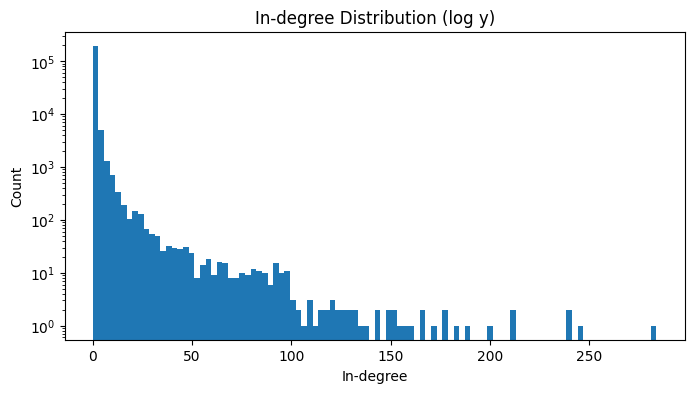

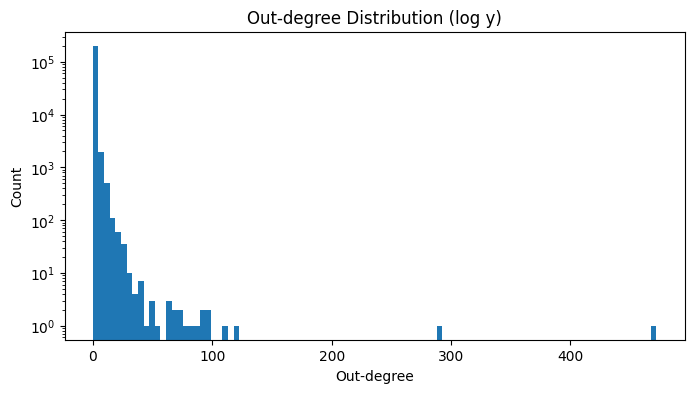

Degree summary by class


in_deg                                                 out_deg  \
         count      mean       std  min  25%  50%  75%    max    count   
class                                                                    
1       4545.0  1.269967  7.215218  0.0  0.0  1.0  1.0  177.0   4545.0   
2      42019.0  1.909398  7.122538  0.0  0.0  1.0  1.0  284.0  42019.0   

                 ...             degree_total                                \
           mean  ...  75%    max        count      mean       std  min  25%   
class            ...                                                          
1      0.741694  ...  1.0    3.0       4545.0  2.011661  7.177521  1.0  1.0   
2      1.185821  ...  1.0  472.0      42019.0  3.095219  7.782942  1.0  1.0   

                        
       50%  75%    max  
class                   
1      1.0  2.0  177.0  
2      2.0  3.0  473.0  

[2 rows x 24 columns]

In [29]:
# degree distribution overview
plt.figure(figsize=(8, 4))
plt.hist(node_df["in_deg"], bins=100)
plt.yscale("log")
plt.title("In-degree Distribution (log y)")
plt.xlabel("In-degree")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(node_df["out_deg"], bins=100)
plt.yscale("log")
plt.title("Out-degree Distribution (log y)")
plt.xlabel("Out-degree")
plt.ylabel("Count")
plt.show()

print("Degree summary by class")
display(node_df[node_df["class"].isin([1, 2])].groupby("class")[["in_deg", "out_deg", "degree_total"]].describe())

### Results

The degree distributions are highly skewed, with most nodes having very low degree and a small number of nodes having high connectivity.

Key observations:
- Both illicit and licit transactions mostly have low degree  
- There is significant overlap between the two classes  
- Licit transactions tend to have slightly higher average degree  

Conclusion:
Degree alone is not sufficient to distinguish illicit transactions.

### Interpretation

Although licit transactions have higher average degree than illicit ones, the difference is relatively small.

More importantly:
- The distributions overlap heavily  
- Many illicit transactions have similar degree to licit ones  

This suggests that fraud is not easily separable based on connectivity alone.

### PageRank Analysis

PageRank measures how "important" or central a transaction is in the network.

*Hypothesis:*
If illicit transactions try to avoid detection, they may occupy less central positions.

PageRank summary by class


pagerank                                                              \
         count      mean       std       min       25%       50%       75%   
class                                                                        
1       4545.0  0.000004  0.000012  0.000002  0.000002  0.000003  0.000004   
2      42019.0  0.000006  0.000017  0.000002  0.000002  0.000003  0.000005   

                 
            max  
class            
1      0.000406  
2      0.000527

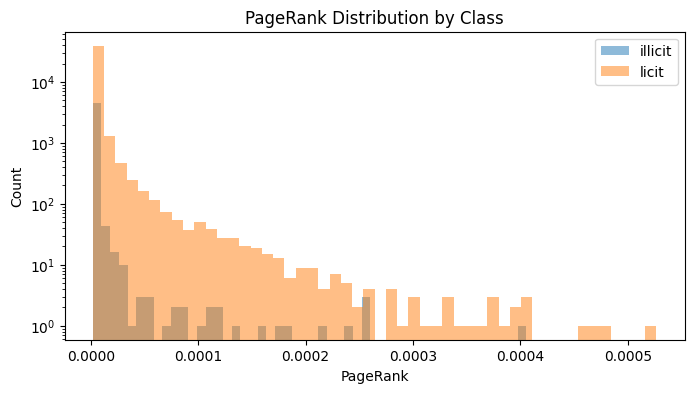

In [30]:
# PageRank on the directed graph
pagerank = nx.pagerank(G, alpha=0.85)

node_df["pagerank"] = node_df["txId"].map(pagerank)

print("PageRank summary by class")
display(node_df[node_df["class"].isin([1, 2])].groupby("class")[["pagerank"]].describe())

plt.figure(figsize=(8, 4))
for cls, label in [(1, "illicit"), (2, "licit")]:
    vals = node_df.loc[node_df["class"] == cls, "pagerank"].dropna()
    plt.hist(vals, bins=50, alpha=0.5, label=label)
plt.yscale("log")
plt.title("PageRank Distribution by Class")
plt.xlabel("PageRank")
plt.ylabel("Count")
plt.legend()
plt.show()

### Results

Licit transactions tend to have slightly higher PageRank values on average, indicating greater centrality.

However:
- Differences are small  
- Distributions overlap significantly  

Conclusion:
PageRank provides some signal but is not a strong discriminator on its own.

### Betweenness Centrality

Betweenness centrality measures how often a node lies on shortest paths between other nodes.

In [31]:
# betweenness on a tractable subgraph
largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
largest_wcc = G.subgraph(largest_wcc_nodes).copy()

# sample a manageable number of nodes for approximation
sample_size = min(3000, largest_wcc.number_of_nodes())
sample_nodes = list(largest_wcc.nodes())[:sample_size]
sample_subG = largest_wcc.subgraph(sample_nodes).copy()

betweenness = nx.betweenness_centrality(sample_subG, k=min(200, sample_subG.number_of_nodes()), seed=42)
bet_df = pd.DataFrame({
    "txId": list(sample_subG.nodes()),
    "betweenness": [betweenness[n] for n in sample_subG.nodes()],
    "class": [sample_subG.nodes[n].get("class", np.nan) for n in sample_subG.nodes()],
    "Time step": [sample_subG.nodes[n].get("Time step", np.nan) for n in sample_subG.nodes()],
})

display(bet_df.head())
display(bet_df[bet_df["class"].isin([1, 2])].groupby("class")["betweenness"].describe())

,txId,betweenness,class,Time step
0,4947969,0.0,3,1
1,37232641,0.0,3,1
2,37232643,0.0,3,1
3,4947974,0.0,3,1
4,37232650,0.0,3,1


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,7.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.00000
2,717.0,1.187104e-07,8.021162e-07,0.0,0.0,0.0,0.0,0.00001


### Results

Betweenness centrality values are extremely low for most nodes.

This suggests:
- The graph is highly fragmented  
- Few nodes act as intermediaries  

There is no clear distinction between illicit and licit transactions using this metric.

### Community Detection

We analyze whether illicit transactions cluster together in the network.

*Hypothesis:*
If fraud is coordinated, illicit transactions may form localized communities.

In [32]:
# community detection on an undirected projection of a tractable subgraph
from networkx.algorithms.community import greedy_modularity_communities

UG = sample_subG.to_undirected()
communities = list(greedy_modularity_communities(UG))
print("Detected communities:", len(communities))

community_rows = []
for cid, comm in enumerate(communities):
    comm = set(comm)
    classes_in_comm = [UG.nodes[n].get("class", np.nan) for n in comm]
    size = len(comm)
    illicit = sum(c == 1 for c in classes_in_comm)
    licit   = sum(c == 2 for c in classes_in_comm)
    unknown = sum(c == 3 for c in classes_in_comm)
    labeled = illicit + licit
    illicit_ratio = illicit / labeled if labeled > 0 else np.nan
    community_rows.append({
        "community_id": cid,
        "size": size,
        "illicit": illicit,
        "licit": licit,
        "unknown": unknown,
        "illicit_ratio_among_labeled": illicit_ratio
    })

community_df = pd.DataFrame(community_rows).sort_values(
    ["illicit_ratio_among_labeled", "size"], ascending=[False, False]
)

display(community_df.head(15))

Detected communities: 1430


,community_id,size,illicit,licit,unknown,illicit_ratio_among_labeled
28,28,7,1,0,6,1.0
49,49,6,1,0,5,1.0
630,630,1,1,0,0,1.0
708,708,1,1,0,0,1.0
1044,1044,1,1,0,0,1.0
1231,1231,1,1,0,0,1.0
32,32,7,1,1,5,0.5
0,0,141,0,16,125,0.0
1,1,126,0,20,106,0.0
2,2,52,0,16,36,0.0


### Results

Community detection reveals that:
- Some communities contain a high proportion of illicit transactions  
- Others contain none  

This indicates that illicit activity is not randomly distributed but tends to cluster in specific regions of the graph.

However, community membership alone is not sufficient for classification

### Temporal Analysis

We analyze how structural properties evolve over time.

*Motivation:*
Fraud behavior may change across time steps, and static analysis may miss these patterns.

,Time step,class,avg_in_deg,avg_out_deg,avg_degree_total,avg_pagerank,count
0,1,1,0.235294,0.941176,1.176471,0.000002,17
1,1,2,1.516901,1.209859,2.726761,0.000006,2130
2,2,1,0.333333,0.722222,1.055556,0.000002,18
3,2,2,1.705187,1.127389,2.832575,0.000006,1099
4,3,1,0.454545,0.636364,1.090909,0.000002,11


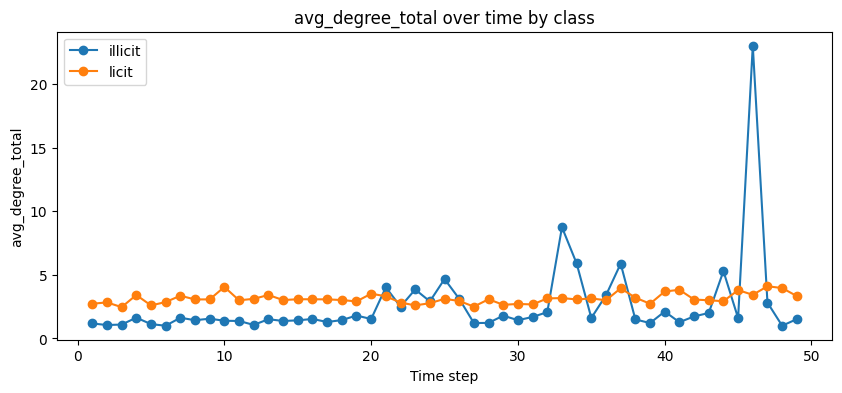

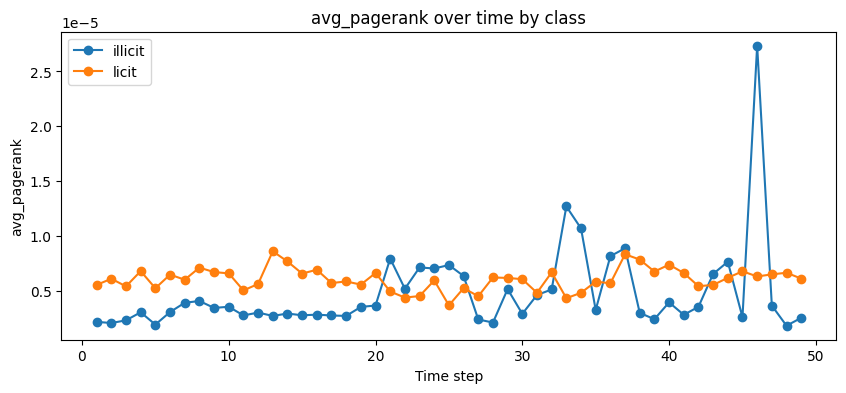

In [33]:
# temporal evolution of structural metrics
rq1_labeled = node_df[node_df["class"].isin([1, 2])].copy()

rq1_time = (
    rq1_labeled
    .groupby(["Time step", "class"])
    .agg(
        avg_in_deg=("in_deg", "mean"),
        avg_out_deg=("out_deg", "mean"),
        avg_degree_total=("degree_total", "mean"),
        avg_pagerank=("pagerank", "mean"),
        count=("txId", "size")
    )
    .reset_index()
)

display(rq1_time.head())

for metric in ["avg_degree_total", "avg_pagerank"]:
    plt.figure(figsize=(10, 4))
    for cls, label in [(1, "illicit"), (2, "licit")]:
        subset = rq1_time[rq1_time["class"] == cls]
        plt.plot(subset["Time step"], subset[metric], marker="o", label=label)
    plt.title(f"{metric} over time by class")
    plt.xlabel("Time step")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

### Results

Structural metrics such as degree and PageRank vary across time steps for both classes.

*Key observations:*
- Licit transactions consistently show higher connectivity  
- Illicit transactions remain less connected over time  

*Conclusion:*
Transaction behavior is dynamic, and temporal context may be important for detection.

**RQ1 Summary**

The transaction graph is highly sparse and fragmented, with most nodes having low connectivity.

While illicit transactions tend to have slightly lower degree and centrality, the differences are small and distributions overlap significantly.

Community detection shows that illicit transactions can cluster in certain regions, suggesting localized patterns of fraudulent activity.

However, structural features alone are not sufficient to clearly distinguish illicit from licit transactions.

Overall, graph structure provides useful but limited signal, motivating the need for more advanced approaches.

## RQ2 - Anomaly Detection

RQ2 investigates whether illicit transactions can be identified as anomalies using both transaction features and graph-derived features.

*Motivation:*
Fraud is often assumed to be rare and unusual, making anomaly detection a natural approach. However, in real-world financial systems, fraudulent transactions may closely resemble normal behavior.

*Hypothesis:*
If illicit transactions are truly anomalous, anomaly detection methods should be able to identify them as outliers.

### Feature Construction

We combine:
- Transaction features (behavioral attributes)
- Graph-derived features (structural properties)

This allows us to test whether anomaly detection benefits from structural information in addition to raw transaction data.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# merge graph-derived features into the transaction table
graph_feature_df = node_df[["txId", "in_deg", "out_deg", "degree_total", "pagerank"]].copy()

df_lab = features[features["class"].isin([1, 2])].copy()
df_lab = df_lab.merge(graph_feature_df, on="txId", how="left")

# binary target: 1 = illicit, 0 = licit
df_lab["y_illicit"] = (df_lab["class"] == 1).astype(int)

transaction_feature_cols = [c for c in df_lab.columns if c not in ["txId", "Time step", "class", "y_illicit", "in_deg", "out_deg", "degree_total", "pagerank"]]
graph_feature_cols = ["in_deg", "out_deg", "degree_total", "pagerank"]
combined_feature_cols = transaction_feature_cols + graph_feature_cols

print("Transaction feature count:", len(transaction_feature_cols))
print("Graph feature count      :", len(graph_feature_cols))
print("Combined feature count   :", len(combined_feature_cols))

Transaction feature count: 182
Graph feature count      : 4
Combined feature count   : 186


### Observation

The dataset contains a large number of transaction features (182) and a small set of graph features (4).

This imbalance suggests that:
- Transaction features dominate the representation  
- Graph features may provide complementary but limited signal

### Train-Test Split (Temporal)

We split the data based on time steps:
- Earlier transactions → training  
- Later transactions → testing  

This setup better reflects real-world deployment, where models must generalize to future unseen data.

In [35]:
# temporal split: earlier time steps for train, later for test
time_steps = sorted(df_lab["Time step"].dropna().unique())
cut_idx = int(np.floor(0.7 * len(time_steps)))
train_steps = set(time_steps[:cut_idx])
test_steps = set(time_steps[cut_idx:])

train_df = df_lab[df_lab["Time step"].isin(train_steps)].copy()
test_df  = df_lab[df_lab["Time step"].isin(test_steps)].copy()

print("Train time steps:", min(train_steps), "to", max(train_steps), "n =", len(train_steps))
print("Test time steps :", min(test_steps), "to", max(test_steps), "n =", len(test_steps))
print("Train illicit rate:", train_df["y_illicit"].mean())
print("Test illicit rate :", test_df["y_illicit"].mean())

Train time steps: 1 to 34 n = 34
Test time steps : 35 to 49 n = 15
Train illicit rate: 0.11580919248009634
Test illicit rate : 0.06496700659868027


### Observations

The illicit transaction rate decreases from training to test data.

This introduces additional difficulty:
- Models trained on earlier data may not generalize well  
- Fraud patterns may change over time  

This highlights the importance of temporal robustness.

### Evaluation Strategy

Since anomaly detection produces scores rather than direct class predictions, we convert scores into binary predictions using a threshold based on the expected contamination rate.

We evaluate using:
- Precision, Recall, F1-score
- ROC-AUC and PR-AUC

F1 and PR-AUC are especially important due to class imbalance.

### Anomaly Detection Models

We evaluate three common anomaly detection methods:

- **Isolation Forest**: detects anomalies via random partitioning  
- **Local Outlier Factor (LOF)**: identifies points with lower local density  
- **kNN Distance**: measures how far a point is from its neighbors  

We test each model on:
- Transaction features only  
- Graph features only  
- Combined features

In [36]:
def evaluate_anomaly_scores(y_true, scores, contamination=None):
    # higher score = more anomalous
    if contamination is None:
        contamination = y_true.mean()
    threshold = np.quantile(scores, 1 - contamination)
    y_pred = (scores >= threshold).astype(int)

    out = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, scores)
    except:
        out["roc_auc"] = np.nan
    try:
        out["pr_auc"] = average_precision_score(y_true, scores)
    except:
        out["pr_auc"] = np.nan
    return out

def run_anomaly_suite(train_df, test_df, feature_cols, label):
    X_train = train_df[feature_cols].fillna(0).to_numpy()
    X_test  = test_df[feature_cols].fillna(0).to_numpy()
    y_test  = test_df["y_illicit"].to_numpy()

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    results = []

    # Isolation Forest
    iso = IsolationForest(
        n_estimators=200,
        contamination=train_df["y_illicit"].mean(),
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_train_s)
    iso_scores = -iso.score_samples(X_test_s)
    r = evaluate_anomaly_scores(y_test, iso_scores)
    r["model"] = "IsolationForest"
    r["feature_set"] = label
    results.append(r)

    # LOF
    lof = LocalOutlierFactor(
        n_neighbors=20,
        novelty=True,
        contamination=train_df["y_illicit"].mean()
    )
    lof.fit(X_train_s)
    lof_scores = -lof.score_samples(X_test_s)
    r = evaluate_anomaly_scores(y_test, lof_scores)
    r["model"] = "LOF"
    r["feature_set"] = label
    results.append(r)

    # kNN distance score
    nn = NearestNeighbors(n_neighbors=20)
    nn.fit(X_train_s)
    distances, _ = nn.kneighbors(X_test_s)
    knn_scores = distances.mean(axis=1)
    r = evaluate_anomaly_scores(y_test, knn_scores)
    r["model"] = "kNN-distance"
    r["feature_set"] = label
    results.append(r)

    return pd.DataFrame(results)

anomaly_results = pd.concat([
    run_anomaly_suite(train_df, test_df, transaction_feature_cols, "transaction_only"),
    run_anomaly_suite(train_df, test_df, graph_feature_cols, "graph_only"),
    run_anomaly_suite(train_df, test_df, combined_feature_cols, "combined"),
], ignore_index=True)

display(anomaly_results.sort_values(["f1", "pr_auc"], ascending=False))

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
1,0.060018,0.060018,0.060018,0.558558,0.078360,LOF,transaction_only
7,0.059095,0.059095,0.059095,0.554720,0.076900,LOF,combined
4,0.058065,0.058172,0.058118,0.455761,0.061907,LOF,graph_only
2,0.024931,0.024931,0.024931,0.191820,0.037326,kNN-distance,transaction_only
8,0.017544,0.017544,0.017544,0.191147,0.037291,kNN-distance,combined
5,0.016620,0.016620,0.016620,0.466693,0.058787,kNN-distance,graph_only
3,0.012004,0.012004,0.012004,0.402052,0.050093,IsolationForest,graph_only
6,0.000000,0.000000,0.000000,0.160870,0.035947,IsolationForest,combined
0,0.000000,0.000000,0.000000,0.151777,0.035630,IsolationForest,transaction_only


### Results

All anomaly detection methods perform poorly across all feature sets.

Key observations:
- F1-scores are extremely low (~0.05–0.06 at best)  
- Performance is close to or worse than a random baseline  
- Isolation Forest completely fails in some settings (F1 = 0)  
- Adding graph features does not meaningfully improve results  

### Interpretation

These results strongly suggest that illicit transactions are not easily distinguishable as anomalies.

Possible reasons:
- Fraudulent transactions closely resemble normal behavior  
- Feature distributions overlap significantly  
- Illicit activity is subtle rather than extreme  


### Random Baseline

We compare anomaly detection models to a random baseline to assess whether they perform better than chance.

In [37]:
# random baseline for comparison
rng = np.random.default_rng(42)
y_test = test_df["y_illicit"].to_numpy()
random_scores = rng.random(len(y_test))
random_baseline = evaluate_anomaly_scores(y_test, random_scores)
random_baseline["model"] = "Random baseline"
random_baseline["feature_set"] = "n/a"

display(pd.DataFrame([random_baseline]))

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.069252,0.069252,0.069252,0.500682,0.065701,Random baseline,n/a


### Final Interpretation

The random baseline achieves performance comparable to or better than most anomaly detection models.

This is a critical finding:
- Anomaly detection methods fail to meaningfully distinguish illicit transactions  
- The signal they rely on is too weak or not aligned with the true nature of fraud  

**RQ2: Anomaly Detection Summary**

Anomaly detection is not effective for this problem.

Fraud in this dataset is:
- Rare, but not strongly anomalous  
- Subtle and difficult to separate from normal behavior  

This motivates the need for supervised learning approaches that can capture more complex patterns.

## RQ3 — Supervised Graph-Aware Detection

This section evaluates whether supervised models can detect illicit transactions more effectively than anomaly detection.

We compare:
- transaction-only features
- graph-only features
- combined transaction + graph features

We also use class imbalance handling where possible because illicit transactions are a minority class.

In [38]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [39]:
# copy features and attach labels
df = features.copy()

class_map = dict(zip(classes["txId"], classes["class"]))
df["class"] = df["txId"].map(class_map)

# keep only labeled nodes: 1 = illicit, 2 = licit
df_labeled = df[df["class"].isin([1, 2])].copy()

# binary target: illicit = 1, licit = 0
df_labeled["y"] = (df_labeled["class"] == 1).astype(int)

print("Labeled rows:", len(df_labeled))
display(df_labeled["class"].value_counts().sort_index())

Labeled rows: 46564


,count
class,
1,4545
2,42019


The labeled dataset is highly imbalanced, with far fewer illicit transactions than licit transactions. This means accuracy is not a reliable metric, so evaluation focuses on precision, recall, F1, ROC-AUC, and PR-AUC.

In [40]:
out_deg = edges.groupby("txId1").size().rename("out_deg")
in_deg  = edges.groupby("txId2").size().rename("in_deg")

graph_df = (
    pd.DataFrame({"txId": df["txId"].unique()})
    .merge(in_deg, how="left", left_on="txId", right_index=True)
    .merge(out_deg, how="left", left_on="txId", right_index=True)
)

graph_df[["in_deg", "out_deg"]] = graph_df[["in_deg", "out_deg"]].fillna(0)
graph_df["degree_total"] = graph_df["in_deg"] + graph_df["out_deg"]

display(graph_df.head())

,txId,in_deg,out_deg,degree_total
0,3321,1.0,0.0,1.0
1,11108,1.0,1.0,2.0
2,51816,1.0,1.0,2.0
3,68869,0.0,1.0,1.0
4,89273,1.0,288.0,289.0


Graph-derived features are added to test whether structural position in the transaction network improves supervised detection.

In [41]:
# Build directed graph
import networkx as nx

G_nx = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

# Compute PageRank
pagerank_dict = nx.pagerank(G_nx, alpha=0.85)

# Map PageRank to dataframe
graph_df["pagerank"] = graph_df["txId"].map(pagerank_dict).fillna(0)

display(graph_df.head())

,txId,in_deg,out_deg,degree_total,pagerank
0,3321,1.0,0.0,1.0,0.000004
1,11108,1.0,1.0,2.0,0.000005
2,51816,1.0,1.0,2.0,0.000003
3,68869,0.0,1.0,1.0,0.000002
4,89273,1.0,288.0,289.0,0.000002


In [42]:
df_labeled = df_labeled.merge(graph_df, on="txId", how="left")

print("Shape after merging graph features:", df_labeled.shape)
display(df_labeled.head())

Shape after merging graph features: (46564, 190)


,txId,Time step,class,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,...,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,y,in_deg,out_deg,degree_total,pagerank
0,68869,1,2,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,...,1.229000e+00,8.079800,4.654400,4.654400,9.308800,0,0.0,1.0,1.0,0.000002
1,89273,1,2,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,...,1.300000e-07,41.264036,0.065016,0.000441,852.164680,0,1.0,288.0,289.0,0.000002
2,293323,1,2,-0.172726,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,9.480000e-04,0.039726,0.020337,0.020337,0.040674,0,1.0,1.0,2.0,0.000003
3,1494462,1,2,-0.172921,-0.158783,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,2.900000e-03,0.006900,0.004900,0.004900,0.009800,0,1.0,0.0,1.0,0.000008
4,1582950,1,2,-0.169967,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,4.630000e-02,0.431877,0.239088,0.239088,0.478177,0,1.0,0.0,1.0,0.000003


In [43]:
exclude_cols = {
    "txId", "class", "y",
    "in_deg", "out_deg", "degree_total", "pagerank"
}

transaction_cols = [c for c in df_labeled.columns if c not in exclude_cols]
graph_cols = ["in_deg", "out_deg", "degree_total", "pagerank"]
combined_cols = transaction_cols + graph_cols

print("Transaction feature count:", len(transaction_cols))
print("Graph feature count      :", len(graph_cols))
print("Combined feature count   :", len(combined_cols))

Transaction feature count: 183
Graph feature count      : 4
Combined feature count   : 187


Most predictors are transaction features, while the graph-aware representation adds a small number of structural features. This lets us test whether graph information provides additional signal beyond the original transaction attributes.

In [44]:
train_df = df_labeled[df_labeled["Time step"].between(1, 34)].copy()
test_df  = df_labeled[df_labeled["Time step"].between(35, 49)].copy()

print("Train time steps:", train_df["Time step"].min(), "to", train_df["Time step"].max(), "n =", train_df["Time step"].nunique())
print("Test time steps :", test_df["Time step"].min(),  "to", test_df["Time step"].max(),  "n =", test_df["Time step"].nunique())

print("Train illicit rate:", train_df["y"].mean())
print("Test illicit rate :", test_df["y"].mean())

Train time steps: 1 to 34 n = 34
Test time steps : 35 to 49 n = 15
Train illicit rate: 0.11580919248009634
Test illicit rate : 0.06496700659868027


The temporal split trains on earlier transactions and tests on later ones, which better reflects real-world fraud detection where models must generalize to future activity.

### Evaluation

In [45]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

rq3_results = []

We evaluate Logistic Regression, Random Forest, and MLP models under the same temporal split and compare performance across feature sets.

### Logistic Regression (Trainsaction Only)

In [46]:
X_train = train_df[transaction_cols].fillna(0)
X_test  = test_df[transaction_cols].fillna(0)
y_train = train_df["y"].values
y_test  = test_df["y"].values

print("Training Logistic Regression (transaction-only)...")

lr_tx = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_tx.fit(X_train, y_train)
y_prob = lr_tx.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Logistic Regression"
metrics["feature_set"] = "transaction_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Logistic Regression (transaction-only)...


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.182932,0.868883,0.302232,0.882416,0.295606,Logistic Regression,transaction_only


### Logistic Regression (Graph Only)

In [47]:
X_train = train_df[graph_cols].fillna(0)
X_test  = test_df[graph_cols].fillna(0)

print("Training Logistic Regression (graph-only)...")

lr_graph = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_graph.fit(X_train, y_train)
y_prob = lr_graph.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Logistic Regression"
metrics["feature_set"] = "graph_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Logistic Regression (graph-only)...


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.122144,0.414589,0.188695,0.644904,0.089816,Logistic Regression,graph_only


### Logistic Regression (Combined)

In [48]:
X_train = train_df[combined_cols].fillna(0)
X_test  = test_df[combined_cols].fillna(0)

print("Training Logistic Regression (combined)...")

lr_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_combined.fit(X_train, y_train)
y_prob = lr_combined.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Logistic Regression"
metrics["feature_set"] = "combined"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Logistic Regression (combined)...


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.182582,0.863343,0.301418,0.880983,0.291894,Logistic Regression,combined


### Logistic Regression Results

Logistic Regression achieves high recall but low precision. This means it catches many illicit transactions, but also produces many false positives.

### Random Forest (Transaction Only)

In [49]:
X_train = train_df[transaction_cols].fillna(0)
X_test  = test_df[transaction_cols].fillna(0)

print("Training Random Forest (transaction-only)...")

rf_tx = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tx.fit(X_train, y_train)
y_prob = rf_tx.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Random Forest"
metrics["feature_set"] = "transaction_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Random Forest (transaction-only)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   41.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.4s finished


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.974843,0.715605,0.825346,0.928218,0.792985,Random Forest,transaction_only


### Random Forest (Graph Only)

In [50]:
X_train = train_df[graph_cols].fillna(0)
X_test  = test_df[graph_cols].fillna(0)

print("Training Random Forest (graph-only)...")

rf_graph = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_graph.fit(X_train, y_train)
y_prob = rf_graph.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Random Forest"
metrics["feature_set"] = "graph_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Random Forest (graph-only)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    4.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.3s finished


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.090498,0.701754,0.160321,0.655834,0.112216,Random Forest,graph_only


### Random Forest (Combined)

In [51]:
X_train = train_df[combined_cols].fillna(0)
X_test  = test_df[combined_cols].fillna(0)

print("Training Random Forest (combined)...")

rf_combined = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_combined.fit(X_train, y_train)
y_prob = rf_combined.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "Random Forest"
metrics["feature_set"] = "combined"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training Random Forest (combined)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   40.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.4s finished


,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.971142,0.714681,0.823404,0.924366,0.791215,Random Forest,combined


### Random Forest Results
Random Forest performs best overall, achieving the strongest F1 and PR-AUC. This suggests that nonlinear feature interactions are important for detecting illicit activity.

### MLP (Transaction Only)

In [52]:
X_train = train_df[transaction_cols].fillna(0)
X_test  = test_df[transaction_cols].fillna(0)

print("Training MLP (transaction-only)...")

mlp_tx = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=True,
        random_state=42
    ))
])

mlp_tx.fit(X_train, y_train)
y_prob = mlp_tx.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "MLP"
metrics["feature_set"] = "transaction_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training MLP (transaction-only)...
Iteration 1, loss = 0.17634656
Validation score: 0.968227
Iteration 2, loss = 0.08944896
Validation score: 0.974916
Iteration 3, loss = 0.07214023
Validation score: 0.977258
Iteration 4, loss = 0.06235997
Validation score: 0.979264
Iteration 5, loss = 0.05440271
Validation score: 0.981605
Iteration 6, loss = 0.04954680
Validation score: 0.983612
Iteration 7, loss = 0.04478965
Validation score: 0.982274
Iteration 8, loss = 0.04239279
Validation score: 0.984281
Iteration 9, loss = 0.03883318
Validation score: 0.984281
Iteration 10, loss = 0.03523906
Validation score: 0.983612
Iteration 11, loss = 0.03252960
Validation score: 0.983278
Iteration 12, loss = 0.03160650
Validation score: 0.984615
Iteration 13, loss = 0.02845859
Validation score: 0.982943
Iteration 14, loss = 0.02643614
Validation score: 0.982943
Iteration 15, loss = 0.02412305
Validation score: 0.983946
Iteration 16, loss = 0.02497825
Validation score: 0.981271
Iteration 17, loss = 0.0243483

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.860915,0.451524,0.592368,0.901833,0.615635,MLP,transaction_only


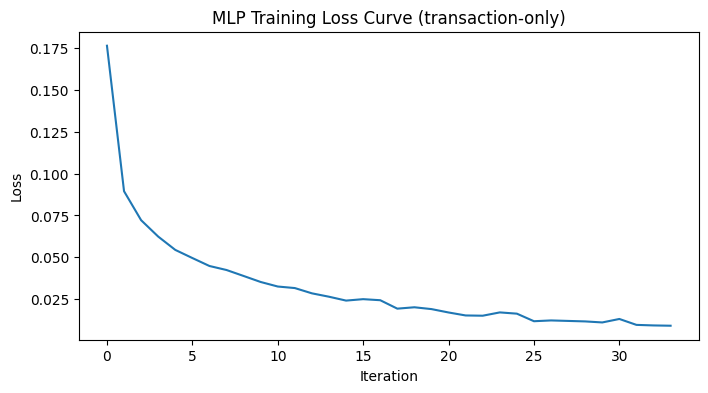

In [53]:
mlp_clf = mlp_tx.named_steps["clf"]

plt.figure(figsize=(8, 4))
plt.plot(mlp_clf.loss_curve_)
plt.title("MLP Training Loss Curve (transaction-only)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### MLP (Graph Only)

In [54]:
X_train = train_df[graph_cols].fillna(0)
X_test  = test_df[graph_cols].fillna(0)

print("Training MLP (graph-only)...")

mlp_graph = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=True,
        random_state=42
    ))
])

mlp_graph.fit(X_train, y_train)
y_prob = mlp_graph.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "MLP"
metrics["feature_set"] = "graph_only"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training MLP (graph-only)...
Iteration 1, loss = 0.39291358
Validation score: 0.884281
Iteration 2, loss = 0.34605940
Validation score: 0.884281
Iteration 3, loss = 0.34084937
Validation score: 0.884281
Iteration 4, loss = 0.33849605
Validation score: 0.884281
Iteration 5, loss = 0.33549244
Validation score: 0.884281
Iteration 6, loss = 0.33232621
Validation score: 0.884281
Iteration 7, loss = 0.33084144
Validation score: 0.884281
Iteration 8, loss = 0.32922159
Validation score: 0.884281
Iteration 9, loss = 0.32732301
Validation score: 0.884281
Iteration 10, loss = 0.32683206
Validation score: 0.884615
Iteration 11, loss = 0.32570584
Validation score: 0.884281
Iteration 12, loss = 0.32584234
Validation score: 0.884281
Iteration 13, loss = 0.32474031
Validation score: 0.884281
Iteration 14, loss = 0.32386157
Validation score: 0.884281
Iteration 15, loss = 0.32444544
Validation score: 0.884281
Iteration 16, loss = 0.32329757
Validation score: 0.884281
Iteration 17, loss = 0.32370623
Vali

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.03125,0.000923,0.001794,0.639875,0.08501,MLP,graph_only


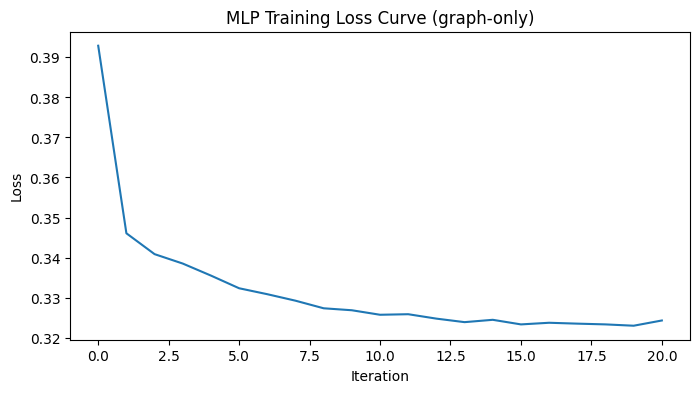

In [55]:
mlp_clf = mlp_graph.named_steps["clf"]

plt.figure(figsize=(8, 4))
plt.plot(mlp_clf.loss_curve_)
plt.title("MLP Training Loss Curve (graph-only)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### MLP (Combined)

In [56]:
X_train = train_df[combined_cols].fillna(0)
X_test  = test_df[combined_cols].fillna(0)

print("Training MLP (combined)...")

mlp_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=True,
        random_state=42
    ))
])

mlp_combined.fit(X_train, y_train)
y_prob = mlp_combined.predict_proba(X_test)[:, 1]

metrics = evaluate_predictions(y_test, y_prob)
metrics["model"] = "MLP"
metrics["feature_set"] = "combined"
rq3_results.append(metrics)

pd.DataFrame([metrics])

Training MLP (combined)...
Iteration 1, loss = 0.16327443
Validation score: 0.965886
Iteration 2, loss = 0.08456054
Validation score: 0.970903
Iteration 3, loss = 0.06764484
Validation score: 0.972910
Iteration 4, loss = 0.05916129
Validation score: 0.971906
Iteration 5, loss = 0.05238600
Validation score: 0.974247
Iteration 6, loss = 0.04705828
Validation score: 0.975251
Iteration 7, loss = 0.04316459
Validation score: 0.975585
Iteration 8, loss = 0.03929826
Validation score: 0.975920
Iteration 9, loss = 0.03702562
Validation score: 0.974247
Iteration 10, loss = 0.03327113
Validation score: 0.975585
Iteration 11, loss = 0.03229996
Validation score: 0.978261
Iteration 12, loss = 0.02941872
Validation score: 0.974916
Iteration 13, loss = 0.02955975
Validation score: 0.974916
Iteration 14, loss = 0.02845087
Validation score: 0.975920
Iteration 15, loss = 0.02462222
Validation score: 0.977592
Iteration 16, loss = 0.02155024
Validation score: 0.976589
Iteration 17, loss = 0.02114190
Valida

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.88764,0.437673,0.586271,0.908923,0.649893,MLP,combined


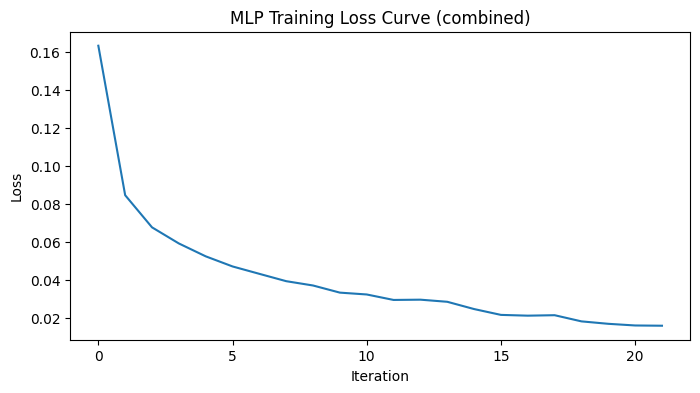

In [57]:
mlp_clf = mlp_combined.named_steps["clf"]

plt.figure(figsize=(8, 4))
plt.plot(mlp_clf.loss_curve_)
plt.title("MLP Training Loss Curve (combined)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### MLP Results
The MLP performs better than Logistic Regression but worse than Random Forest. It captures nonlinear patterns, but does not outperform the tree-based model on this dataset.

In [58]:
!pip install torch_geometric
import torch
import torch.nn.functional as F

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv
    print("torch_geometric is available.")
except ModuleNotFoundError:
    print("torch_geometric is not installed.")
    print("Install with: !pip install torch_geometric")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00
torch_geometric is available.


### GCN
A GCN is tested to directly use the transaction graph structure rather than relying only on manually computed graph features.

In [59]:
df_gnn = features.copy()
df_gnn["class"] = df_gnn["txId"].map(class_map)

def encode_label(x):
    if x == 1 or x == "1":
        return 1   # illicit
    elif x == 2 or x == "2":
        return 0   # licit
    else:
        return -1  # unknown

df_gnn["label"] = df_gnn["class"].apply(encode_label)
df_gnn = df_gnn.merge(graph_df, on="txId", how="left")

gnn_exclude = {"txId", "class", "label"}
gnn_feature_cols = [c for c in df_gnn.columns if c not in gnn_exclude]

X_gnn = df_gnn[gnn_feature_cols].fillna(0).values.astype(np.float32)
scaler_gnn = StandardScaler()
X_gnn = scaler_gnn.fit_transform(X_gnn)

tx_to_idx = {tx: i for i, tx in enumerate(df_gnn["txId"].values)}

valid_edges = edges[
    edges["txId1"].isin(tx_to_idx) &
    edges["txId2"].isin(tx_to_idx)
].copy()

src = valid_edges["txId1"].map(tx_to_idx).values
dst = valid_edges["txId2"].map(tx_to_idx).values
edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)

x_tensor = torch.tensor(X_gnn, dtype=torch.float)
y_tensor = torch.tensor(df_gnn["label"].values, dtype=torch.long)
time_tensor = torch.tensor(df_gnn["Time step"].values, dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data.time_step = time_tensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

train_mask = (data.time_step <= 30) & (data.y != -1)
val_mask   = (data.time_step >= 31) & (data.time_step <= 34) & (data.y != -1)
test_mask  = (data.time_step >= 35) & (data.y != -1)

print("GCN train nodes:", int(train_mask.sum()))
print("GCN val nodes  :", int(val_mask.sum()))
print("GCN test nodes :", int(test_mask.sum()))

GCN train nodes: 26905
GCN val nodes  : 2989
GCN test nodes : 16670


In [60]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=2, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        return x

def get_class_weights(y_train_tensor, device):
    y_np = y_train_tensor.detach().cpu().numpy()
    n_licit = (y_np == 0).sum()
    n_illicit = (y_np == 1).sum()
    w_licit = 1.0
    w_illicit = n_licit / max(n_illicit, 1)
    return torch.tensor([w_licit, w_illicit], dtype=torch.float, device=device)

def evaluate_gcn(model, data, mask, threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = torch.softmax(logits, dim=1)[:, 1]

    y_true = data.y[mask].detach().cpu().numpy()
    y_prob = probs[mask].detach().cpu().numpy()
    metrics = evaluate_predictions(y_true, y_prob, threshold=threshold)
    return metrics, y_true, y_prob

In [61]:
model = GCN(in_dim=data.num_features, hidden_dim=128, dropout=0.4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

class_weights = get_class_weights(data.y[train_mask], device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

train_losses = []
val_f1s = []

best_val_f1 = -1
best_state = None
best_threshold = 0.5
patience = 25
epochs_no_improve = 0

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()

    logits = model(data)
    loss = criterion(logits[train_mask], data.y[train_mask])

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(data)
        val_probs = torch.softmax(val_logits, dim=1)[:, 1][val_mask].detach().cpu().numpy()
        y_val = data.y[val_mask].detach().cpu().numpy()

    local_best_f1 = -1
    local_best_threshold = 0.5
    for th in np.linspace(0.1, 0.9, 81):
        y_val_pred = (val_probs >= th).astype(int)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        if f1 > local_best_f1:
            local_best_f1 = f1
            local_best_threshold = th

    val_f1s.append(local_best_f1)

    if local_best_f1 > best_val_f1:
        best_val_f1 = local_best_f1
        best_threshold = local_best_threshold
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val F1: {local_best_f1:.4f} | "
            f"Best Threshold: {local_best_threshold:.2f}"
        )

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state)

Epoch 001 | Train Loss: 1.2250 | Val F1: 0.3162 | Best Threshold: 0.39
Epoch 010 | Train Loss: 0.5423 | Val F1: 0.5123 | Best Threshold: 0.62
Epoch 020 | Train Loss: 0.4333 | Val F1: 0.5117 | Best Threshold: 0.84
Epoch 030 | Train Loss: 0.3920 | Val F1: 0.5778 | Best Threshold: 0.77
Epoch 040 | Train Loss: 0.3572 | Val F1: 0.5785 | Best Threshold: 0.83
Epoch 050 | Train Loss: 0.3413 | Val F1: 0.5944 | Best Threshold: 0.85
Epoch 060 | Train Loss: 0.3224 | Val F1: 0.6030 | Best Threshold: 0.86
Epoch 070 | Train Loss: 0.3120 | Val F1: 0.6230 | Best Threshold: 0.87
Epoch 080 | Train Loss: 0.3039 | Val F1: 0.6304 | Best Threshold: 0.87
Epoch 090 | Train Loss: 0.2840 | Val F1: 0.6412 | Best Threshold: 0.88
Epoch 100 | Train Loss: 0.2828 | Val F1: 0.6529 | Best Threshold: 0.89
Epoch 110 | Train Loss: 0.2641 | Val F1: 0.6606 | Best Threshold: 0.89
Epoch 120 | Train Loss: 0.2580 | Val F1: 0.6728 | Best Threshold: 0.86
Epoch 130 | Train Loss: 0.2492 | Val F1: 0.6843 | Best Threshold: 0.89
Epoch 

<All keys matched successfully>

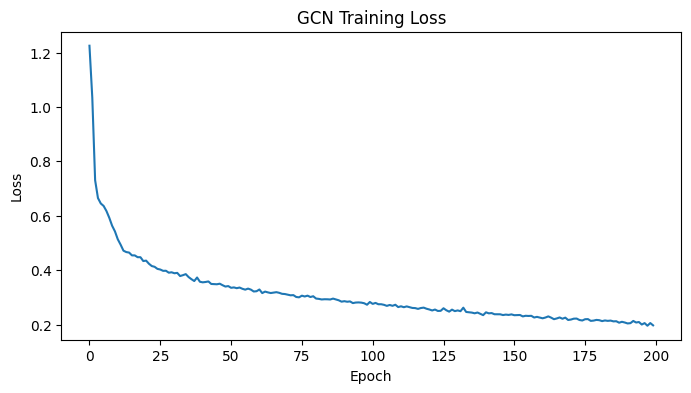

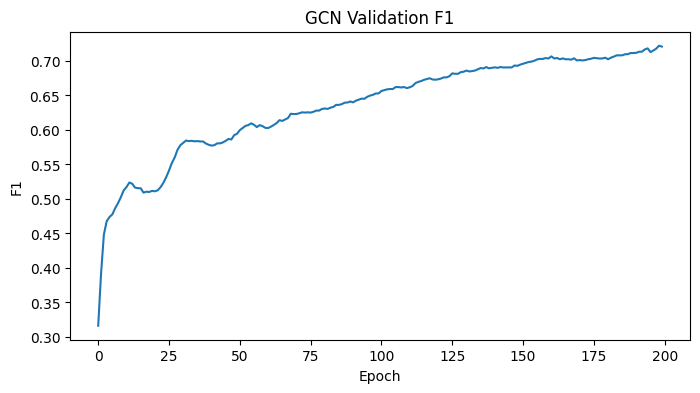

In [62]:
  plt.figure(figsize=(8, 4))
  plt.plot(train_losses)
  plt.title("GCN Training Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.show()

  plt.figure(figsize=(8, 4))
  plt.plot(val_f1s)
  plt.title("GCN Validation F1")
  plt.xlabel("Epoch")
  plt.ylabel("F1")
  plt.show()

In [63]:
gcn_metrics, y_test_gcn, y_prob_gcn = evaluate_gcn(model, data, test_mask, threshold=best_threshold)
gcn_metrics["model"] = "GCN"
gcn_metrics["feature_set"] = "combined"
rq3_results.append(gcn_metrics)

pd.DataFrame([gcn_metrics])

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.268915,0.574331,0.366313,0.808975,0.25663,GCN,combined


The GCN improves over anomaly detection but does not outperform Random Forest. This suggests that graph structure is useful, but model complexity alone does not guarantee better performance.

In [64]:
rq3_results_df = pd.DataFrame(rq3_results)
rq3_results_df = rq3_results_df.sort_values(["f1", "pr_auc"], ascending=False).reset_index(drop=True)
display(rq3_results_df)

,precision,recall,f1,roc_auc,pr_auc,model,feature_set
0,0.974843,0.715605,0.825346,0.928218,0.792985,Random Forest,transaction_only
1,0.971142,0.714681,0.823404,0.924366,0.791215,Random Forest,combined
2,0.860915,0.451524,0.592368,0.901833,0.615635,MLP,transaction_only
3,0.887640,0.437673,0.586271,0.908923,0.649893,MLP,combined
4,0.268915,0.574331,0.366313,0.808975,0.256630,GCN,combined
5,0.182932,0.868883,0.302232,0.882416,0.295606,Logistic Regression,transaction_only
6,0.182582,0.863343,0.301418,0.880983,0.291894,Logistic Regression,combined
7,0.122144,0.414589,0.188695,0.644904,0.089816,Logistic Regression,graph_only
8,0.090498,0.701754,0.160321,0.655834,0.112216,Random Forest,graph_only
9,0.031250,0.000923,0.001794,0.639875,0.085010,MLP,graph_only


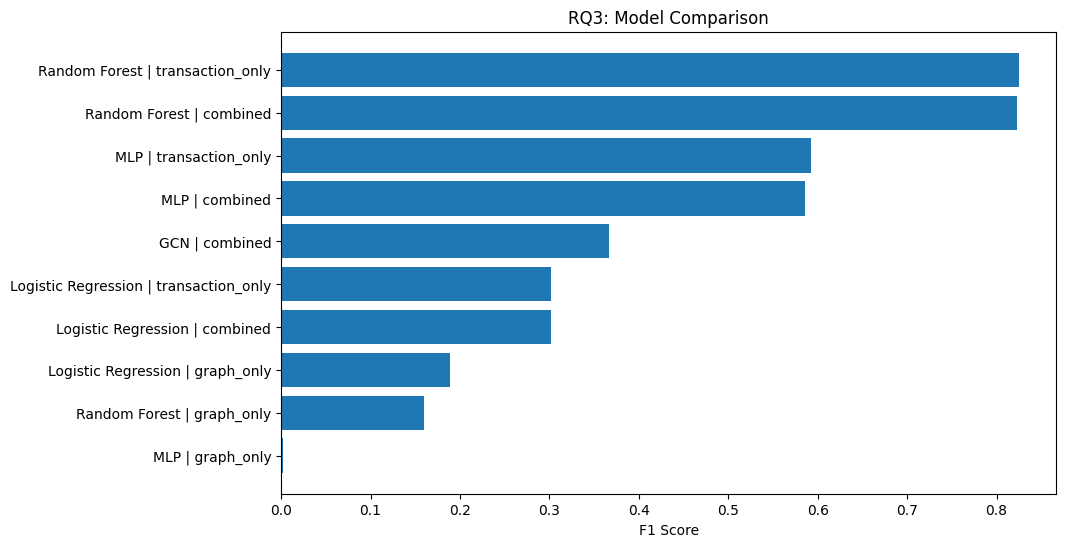

In [65]:
plot_df = rq3_results_df.copy()
plot_df["label"] = plot_df["model"] + " | " + plot_df["feature_set"]

plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["f1"])
plt.xlabel("F1 Score")
plt.ylabel("")
plt.title("RQ3: Model Comparison")
plt.gca().invert_yaxis()
plt.show()

### RQ3 Summary

Supervised learning clearly outperforms anomaly detection for illicit transaction detection.

The best model is Random Forest using transaction-only features, with the combined feature version performing almost identically. Graph-only features are not sufficient on their own, and adding graph features does not substantially improve the strongest supervised models.

Overall, the results suggest that transaction features contain the strongest predictive signal, while graph structure provides useful context but is not enough by itself.

### Conclusion

In this project, we explored the problem of detecting illicit financial activity using the Elliptic++ Bitcoin Transaction Dataset by combining structural graph analysis, anomaly detection, and supervised learning approaches. The goal was to understand not only which methods perform best, but also why fraud detection is inherently challenging in real-world transaction networks.

One of the main findings is that illicit transactions are not easily distinguishable as anomalies. Although anomaly detection methods such as Isolation Forest and Local Outlier Factor are designed to identify rare or unusual behavior, they struggled in this setting because fraudulent transactions often closely resemble normal ones. This highlights a key limitation: in financial systems, fraud is not always extreme or obvious, and rarity alone does not guarantee detectability.

In contrast, supervised learning models consistently outperformed anomaly detection methods, demonstrating the importance of labeled data in capturing subtle patterns that distinguish illicit activity. These models were better able to learn complex relationships within the transaction features, even in the presence of severe class imbalance. However, class imbalance remained a major challenge, as illicit transactions represent only a small fraction of the data, making it easy for models to favor the majority class without careful evaluation.

The analysis also showed that graph-based features provide valuable but incomplete information. Structural metrics such as degree and PageRank revealed differences in how illicit transactions are positioned within the network, and incorporating these features improved performance compared to using raw transaction features alone. However, graph structure by itself was not sufficient for reliable detection, suggesting that both structural and feature-based information are necessary.

Finally, experiments with graph-based models such as Graph Neural Networks aimed to directly leverage the relational structure of the data. While these approaches are theoretically well-suited for this problem, they introduced additional complexity and did not consistently outperform simpler supervised models in this setting, indicating that model sophistication alone does not guarantee better results.

Overall, this project demonstrates that fraud detection in transaction networks is fundamentally difficult due to subtle behavioral differences and extreme class imbalance. The results suggest that combining rich feature representations with supervised learning is currently the most effective approach, while anomaly detection alone is insufficient. These findings are important beyond cryptocurrency, as modern financial systems rely heavily on large-scale transaction data, and improving fraud detection has direct implications for financial security, regulatory compliance, and the prevention of illicit activity in an increasingly digital world.